In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregar todos os dados ATP (tour, qualifiers, challengers e futures)
dfs = []
for year in range(1992, 2025):
    # ATP Tour
    dfs.append(pd.read_csv(f'D:/projetos/Tenis ML-AI/data/tennis_atp/atp_matches_{year}.csv'))
    
    # ATP Qualifiers/Challengers
    try:
        dfs.append(pd.read_csv(f'D:/projetos/Tenis ML-AI/data/tennis_atp/atp_matches_qual_chall_{year}.csv'))
    except FileNotFoundError:
        print(f"Arquivo atp_matches_qual_chall_{year}.csv não encontrado, pulando...")
    
    # ATP Futures
    try:
        dfs.append(pd.read_csv(f'D:/projetos/Tenis ML-AI/data/tennis_atp/atp_matches_futures_{year}.csv'))
    except FileNotFoundError:
        print(f"Arquivo atp_matches_futures_{year}.csv não encontrado, pulando...")

# Concatenar todos os DataFrames
df = pd.concat(dfs)

# Definir as superfícies
surfaces = df['surface'].unique().tolist()
print("Superfícies encontradas:", surfaces)

# Parâmetros do ELO
K_FACTOR = 32  # Fator de ajuste do ELO
INITIAL_ELO = 1500  # ELO inicial para todos os jogadores

# Dicionário para armazenar os ELOs por superfície
elo_by_surface = {}

# Inicializar ELOs para cada superfície
for surface in surfaces:
    if pd.isna(surface):
        continue
    elo_by_surface[surface] = {}

# Função para calcular a probabilidade esperada
def expected_score(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

# Função para atualizar o ELO
def update_elo(winner_elo, loser_elo, K=K_FACTOR):
    expected_win = expected_score(winner_elo, loser_elo)
    change = K * (1 - expected_win)
    winner_elo += change
    loser_elo -= change
    return winner_elo, loser_elo

# Processar cada partida em ordem cronológica
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')
df = df.sort_values('tourney_date')

# Inicializar dicionário para armazenar o ELO atual de cada jogador por superfície
current_elo = {surface: {} for surface in elo_by_surface.keys()}

# Listas para armazenar os ELOs durante o processamento
winner_elos = []
loser_elos = []

for idx, row in df.iterrows():
    surface = row['surface']
    if pd.isna(surface):
        winner_elos.append(np.nan)
        loser_elos.append(np.nan)
        continue
    
    winner_id = row['winner_id']
    loser_id = row['loser_id']
    
    # Obter ELO atual ou usar o inicial
    winner_elo = current_elo[surface].get(winner_id, INITIAL_ELO)
    loser_elo = current_elo[surface].get(loser_id, INITIAL_ELO)
    
    # Armazenar ELOs antes da atualização
    winner_elos.append(winner_elo)
    loser_elos.append(loser_elo)
    
    # Atualizar ELOs
    new_winner_elo, new_loser_elo = update_elo(winner_elo, loser_elo)
    
    # Atualizar no dicionário
    current_elo[surface][winner_id] = new_winner_elo
    current_elo[surface][loser_id] = new_loser_elo

# Adicionar colunas de ELO por superfície ao DataFrame
df['winner_surface_elo'] = winner_elos
df['loser_surface_elo'] = loser_elos

# Salvar os resultados
#df.to_csv('atp_chall_itf_matches_with_surface_elo1.csv', index=False)

Superfícies encontradas: ['Hard', 'Carpet', 'Clay', 'Grass', nan]


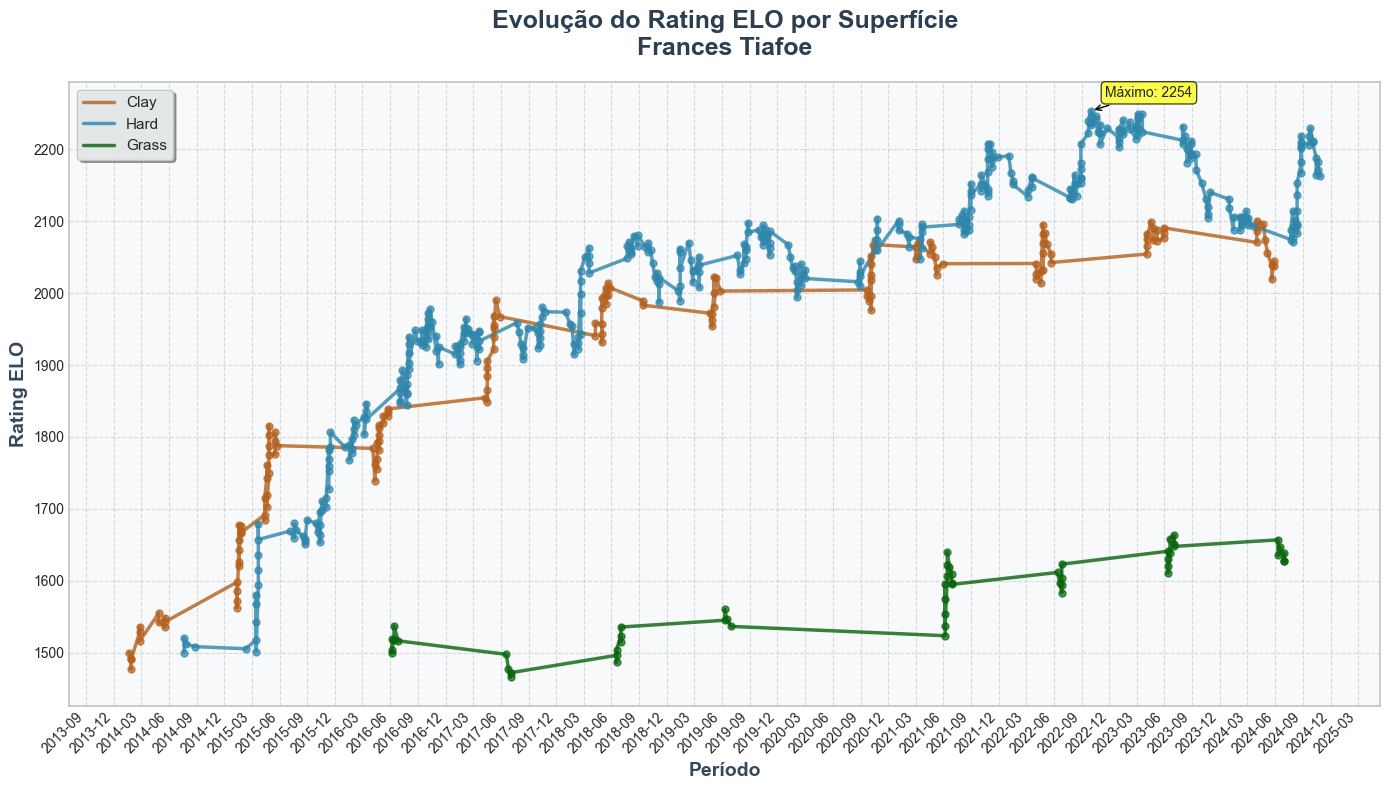

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns

# Configurar estilo global
plt.style.use('seaborn-v0_8-darkgrid')  # ou 'seaborn-darkgrid' em versões mais antigas
sns.set_palette("husl")  # Paleta de cores mais bonita

# Exemplo: Pegar um jogador específico e plotar seu ELO por superfície ao longo do tempo
player_name = "Frances Tiafoe"  # Substitua pelo nome do jogador desejado
player_id = df[df['winner_name'] == player_name]['winner_id'].iloc[0]

# Criar DataFrame com histórico do jogador
player_history = pd.concat([
    df[df['winner_id'] == player_id][['tourney_date', 'surface', 'winner_surface_elo']].rename(
        columns={'winner_surface_elo': 'surface_elo'}),
    df[df['loser_id'] == player_id][['tourney_date', 'surface', 'loser_surface_elo']].rename(
        columns={'loser_surface_elo': 'surface_elo'})
]).sort_values('tourney_date')

# Converter datas se necessário
if not pd.api.types.is_datetime64_any_dtype(player_history['tourney_date']):
    player_history['tourney_date'] = pd.to_datetime(player_history['tourney_date'])

# Configurar figura com melhor aparência
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('#f8f9fa')

# Cores personalizadas para cada superfície
surface_colors = {
    'Hard': '#2E86AB',      # Azul
    'Clay': "#B3601C",      # Laranja
    'Grass': "#06630B",     # Verde
    'Carpet': '#C73E1D'     # Vermelho
}

# Plotar cada superfície com melhor estilo
for surface in player_history['surface'].unique():
    if pd.isna(surface):
        continue
    
    surface_data = player_history[player_history['surface'] == surface].copy()
    
    # Ordenar por data para ter linhas contínuas
    surface_data = surface_data.sort_values('tourney_date')
    
    color = surface_colors.get(surface, '#333333')
    
    # Plotar linha principal
    ax.plot(surface_data['tourney_date'], surface_data['surface_elo'], 
            color=color, linewidth=2.5, label=surface, alpha=0.8)
    
    # Adicionar pontos nos dados
    ax.scatter(surface_data['tourney_date'], surface_data['surface_elo'], 
               color=color, s=25, alpha=0.7, zorder=5)

# Melhorar título e labels
ax.set_title(f'Evolução do Rating ELO por Superfície\n{player_name}', 
             fontsize=18, fontweight='bold', pad=20, color='#2c3e50')

ax.set_xlabel('Período', fontsize=14, fontweight='semibold', color='#34495e')
ax.set_ylabel('Rating ELO', fontsize=14, fontweight='semibold', color='#34495e')

# Melhorar formatação dos eixos
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Personalizar grid
ax.grid(True, linestyle='--', alpha=0.6, color='#bdc3c7', linewidth=0.8)

# Melhorar legenda
legend = ax.legend(loc='upper left', frameon=True, fancybox=True, 
                   shadow=True, framealpha=0.9, fontsize=11)
legend.get_frame().set_facecolor('#ecf0f1')
legend.get_frame().set_edgecolor('#bdc3c7')

# Ajustar margens e layout
plt.tight_layout()

# Melhorar bordas do gráfico
for spine in ax.spines.values():
    spine.set_color('#bdc3c7')
    spine.set_linewidth(1.2)

# Adicionar anotações se necessário (opcional)
# Exemplo: marcar o ELO máximo
max_elo_idx = player_history['surface_elo'].idxmax()
max_elo_data = player_history.loc[max_elo_idx]
ax.annotate(f'Máximo: {max_elo_data["surface_elo"]:.0f}', 
            xy=(max_elo_data['tourney_date'], max_elo_data['surface_elo']),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontsize=10)

plt.show()
plt.close()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
from datetime import datetime

# Exemplo: Pegar um jogador específico e plotar seu ELO por superfície ao longo do tempo
player_name = "Rafael Nadal"  # Substitua pelo nome do jogador desejado
player_id = df[df['winner_name'] == player_name]['winner_id'].iloc[0]

# Criar DataFrame com histórico do jogador
player_history = pd.concat([
    df[df['winner_id'] == player_id][['tourney_date', 'surface', 'winner_surface_elo']].rename(
        columns={'winner_surface_elo': 'surface_elo'}),
    df[df['loser_id'] == player_id][['tourney_date', 'surface', 'loser_surface_elo']].rename(
        columns={'loser_surface_elo': 'surface_elo'})
]).sort_values('tourney_date')

# Converter datas se necessário
if not pd.api.types.is_datetime64_any_dtype(player_history['tourney_date']):
    player_history['tourney_date'] = pd.to_datetime(player_history['tourney_date'])

# Remover valores NaN
player_history = player_history.dropna()

# ========================================
# 1. GRÁFICO INTERATIVO BÁSICO (MELHORADO)
# ========================================

# Cores personalizadas para cada superfície
surface_colors = {
    'Hard': '#2E86AB',
    'Clay': "#C76C17", 
    'Grass': "#135C1D",
    'Carpet': '#C73E1D'
}

fig1 = go.Figure()

for surface in player_history['surface'].unique():
    surface_data = player_history[player_history['surface'] == surface].copy()
    surface_data = surface_data.sort_values('tourney_date')
    
    color = surface_colors.get(surface, '#333333')
    
    # Linha principal com hover personalizado
    fig1.add_trace(go.Scatter(
        x=surface_data['tourney_date'],
        y=surface_data['surface_elo'],
        mode='lines+markers',
        name=surface,
        line=dict(color=color, width=3),
        marker=dict(color=color, size=8, opacity=0.8),
        hovertemplate=f'<b>{surface}</b><br>' +
                     'Data: %{x}<br>' +
                     'ELO: %{y:.0f}<br>' +
                     '<extra></extra>'
    ))

# Layout melhorado
fig1.update_layout(
    title={
        'text': f'<b>Evolução do Rating ELO por Superfície</b><br><sub>{player_name}</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 24, 'color': '#2c3e50'}
    },
    xaxis_title='<b>Período</b>',
    yaxis_title='<b>Rating ELO</b>',
    font=dict(size=12, color='#34495e'),
    plot_bgcolor='#f8f9fa',
    paper_bgcolor='white',
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=.5,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1
    ),
    margin=dict(l=50, r=50, t=100, b=50),
    height=600
)

# Grid personalizado
fig1.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(128,128,128,0.2)')
fig1.update_yaxes(showgrid=True, gridwidth=1, gridcolor='rgba(128,128,128,0.2)')

print("=== GRÁFICO INTERATIVO BÁSICO ===")
fig1.show()

# ========================================
# 3. DASHBOARD COM MÚLTIPLOS GRÁFICOS
# ========================================

# Criar subplots
fig3 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Evolução por Superfície', 'Distribuição de ELO Atual', 
                   'ELO Médio por Superfície', 'Progresso Total'),
    specs=[[{"secondary_y": False}, {"type": "box"}],
           [{"type": "bar"}, {"secondary_y": False}]]
)

# 1. Gráfico principal (canto superior esquerdo)
for surface in player_history['surface'].unique():
    surface_data = player_history[player_history['surface'] == surface].copy()
    surface_data = surface_data.sort_values('tourney_date')
    
    fig3.add_trace(
        go.Scatter(
            x=surface_data['tourney_date'],
            y=surface_data['surface_elo'],
            mode='lines+markers',
            name=surface,
            line=dict(color=surface_colors.get(surface, '#333333'), width=2),
            marker=dict(size=6)
        ),
        row=1, col=1
    )

# 2. Box plot da distribuição atual (canto superior direito)
for surface in player_history['surface'].unique():
    surface_data = player_history[player_history['surface'] == surface]
    fig3.add_trace(
        go.Box(
            y=surface_data['surface_elo'],
            name=surface,
            marker_color=surface_colors.get(surface, '#333333')
        ),
        row=1, col=2
    )

# 3. ELO médio por superfície (canto inferior esquerdo)
avg_elo = player_history.groupby('surface')['surface_elo'].mean().reset_index()
fig3.add_trace(
    go.Bar(
        x=avg_elo['surface'],
        y=avg_elo['surface_elo'],
        marker_color=[surface_colors.get(s, '#333333') for s in avg_elo['surface']],
        showlegend=False
    ),
    row=2, col=1
)

# 4. Progresso geral (canto inferior direito)
overall_progress = player_history.groupby('tourney_date')['surface_elo'].mean().reset_index()
fig3.add_trace(
    go.Scatter(
        x=overall_progress['tourney_date'],
        y=overall_progress['surface_elo'],
        mode='lines+markers',
        name='ELO Médio Geral',
        line=dict(color='#e74c3c', width=3),
        marker=dict(size=8),
        fill='tonexty' if len(overall_progress) > 1 else None
    ),
    row=2, col=2
)

# Layout do dashboard
fig3.update_layout(
    title_text=f"<b>Dashboard Completo - {player_name}</b>",
    title_x=0.5,
    title_font_size=24,
    showlegend=True,
    height=800,
    plot_bgcolor='#f8f9fa',
    paper_bgcolor='white'
)

print("\n=== DASHBOARD COMPLETO ===")
fig3.show()

# ========================================
# 4. GRÁFICO 3D 
# ========================================

# Preparar dados para 3D (adicionar uma dimensão temporal numérica)
player_history_3d = player_history.copy()
player_history_3d['days_since_start'] = (
    player_history_3d['tourney_date'] - player_history_3d['tourney_date'].min()
).dt.days

fig4 = go.Figure()

for surface in player_history_3d['surface'].unique():
    surface_data = player_history_3d[player_history_3d['surface'] == surface].copy()
    surface_data = surface_data.sort_values('tourney_date')
    
    fig4.add_trace(go.Scatter3d(
        x=surface_data['days_since_start'],
        y=[surface] * len(surface_data),  # Usar nome da superfície como coordenada Y
        z=surface_data['surface_elo'],
        mode='lines+markers',
        name=surface,
        line=dict(color=surface_colors.get(surface, '#333333'), width=4),
        marker=dict(color=surface_colors.get(surface, '#333333'), size=6)
    ))

fig4.update_layout(
    title=f'<b>Visualização 3D - ELO ao Longo do Tempo</b><br><sub>{player_name}</sub>',
    title_x=0.5,
    scene=dict(
        xaxis_title='Dias desde o início',
        yaxis_title='Superfície',
        zaxis_title='Rating ELO',
        bgcolor='#f8f9fa'
    ),
    height=700
)

print("\n=== GRÁFICO 3D ===")
fig4.show()

print(f"\n✅ Todos os gráficos foram gerados para o jogador: {player_name}")

=== GRÁFICO INTERATIVO BÁSICO ===



=== DASHBOARD COMPLETO ===



=== GRÁFICO 3D ===



✅ Todos os gráficos foram gerados para o jogador: Rafael Nadal
